In [1]:
import os, json
import pandas as pd
from pathlib import Path
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv("../.env")

client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY"),
    base_url="https://us.api.openai.com/v1"
)
PROMPT_PATH = Path("../prompts/old_prompt.txt")

OUTPUT_DIR = Path("../data/model_eval/gpt_batch")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with open(PROMPT_PATH, "r") as f:
    PROMPT_TEMPLATE = f.read()

VALID_LABELS = [
    "unstoppable_force",
    "future_shaper",
    "natural_disaster",
    "human_replacement",
    "junk_food",
    "weapon_threat",
    "thief",
    "helper_tool",
    "knowledge_retrieval",
    "brain_mind",
    "machine_robot_system",
    "mirror_echo",
    "child",
    "synthesizer_creator",
    "friend",
    "living_creature",
    "unexplored_realm",
    "god",
    "genie_folklore",
]


MODEL = "gpt-4.1"

GPT_PRICES_PER_1M = {
    "gpt-4.1": {"input": 2.00, "output": 8.00},
}

def build_prompt(text):
    return PROMPT_TEMPLATE.replace("{text}", str(text))


def extract_dominant_from_output(raw_output):
    try:
        parsed = json.loads(raw_output)
        counts = parsed.get("metaphor_counts", {})

        if not counts:
            return "None"

        dominant = max(counts.items(), key=lambda x: x[1])[0]

        if counts[dominant] == 0:
            return "None"

        return dominant

    except:
        return "ERROR"


def make_batch_file(df, out_path):
    with open(out_path, "w") as f:
        for i, row in df.reset_index(drop=True).iterrows():

            request = {
                "custom_id": f"{MODEL}__row_{i}",
                "method": "POST",
                "url": "/v1/chat/completions",
                "body": {
                    "model": MODEL,
                    "temperature": 0,
                    "max_tokens": 200,  
                    "messages": [
                        {"role": "system", "content": "Return valid JSON only."},
                        {"role": "user", "content": build_prompt(row["ai_metaphor"])},
                    ],
                },
            }

            f.write(json.dumps(request) + "\n")


def submit_batch(batch_file_path):
    uploaded = client.files.create(
        file=open(batch_file_path, "rb"),
        purpose="batch",
    )

    batch = client.batches.create(
        input_file_id=uploaded.id,
        endpoint="/v1/chat/completions",
        completion_window="24h",
    )

    return batch

In [21]:
df = pd.read_csv('../Data/LLM_Comparison/Metaphor_Data_Myra_Chang.csv')

In [22]:
df['row_id'] = df.index
df = df[['row_id', 'ai_metaphor', 'dominant_metaphor']]

In [24]:
batch_file = OUTPUT_DIR / "gpt41_old_prompt.jsonl"

make_batch_file(df, batch_file)

batch = submit_batch(batch_file)

print("Batch ID:", batch.id)
print("Status:", batch.status)

Batch ID: batch_69ec53703094819098b5cde324cb5aec
Status: validating


In [34]:
batch = client.batches.retrieve(batch.id)
print(batch.status)
print(batch.request_counts)

completed
BatchRequestCounts(completed=11789, failed=0, total=11789)


In [38]:
import json
import pandas as pd

def retrieve_batch_results(batch_id):
    batch = client.batches.retrieve(batch_id)

    if batch.status != "completed":
        print("Batch not completed:", batch.status)
        return None

    content = client.files.content(batch.output_file_id).content.decode("utf-8")

    rows = []

    for line in content.splitlines():
        obj = json.loads(line)

        if obj.get("response") is None:
            continue

        custom_id = obj["custom_id"]
        row_id = int(custom_id.split("__row_")[1])

        body = obj["response"]["body"]

        if "error" in body:
            rows.append({"row_id": row_id, "raw_output": None})
            continue

        raw_output = body["choices"][0]["message"]["content"]

        rows.append({
            "row_id": row_id,
            "raw_output": raw_output
        })

    return pd.DataFrame(rows)


results_df = retrieve_batch_results(batch.id)

In [44]:
import json

def extract_predicted(raw_output):
    try:
        parsed = json.loads(raw_output)
        return parsed.get("dominant_metaphor", "none")
    except:
        return "error"

results_df["predicted_metaphor"] = results_df["raw_output"].apply(extract_predicted)

In [47]:
df

,row_id,ai_metaphor,dominant_metaphor
0,0,genie in a bottle - you can ask it to do anyth...,genie
1,1,Artificial intelligence is a tool that humans ...,tool
2,2,AI is a choose-your-own-adventure book where y...,library
3,3,AI is like a printer or copier machine: extrem...,machine
4,4,AI makes fewer medical mistakes,tool
...,...,...,...
11784,11784,AI is like A personal concierge. because It wi...,assistant
11785,11785,AI is like My goto because AI is my go to for....,tool
11786,11786,AI is like The Jetsons because this is the fut...,robot
11787,11787,AI is like an personal assistant . because it ...,assistant


In [49]:
final_df = df.merge(results_df[['row_id', 'predicted_metaphor']], on='row_id', how='left')
final_df = final_df[['ai_metaphor', 'dominant_metaphor', 'predicted_metaphor']]
final_df

,ai_metaphor,dominant_metaphor,predicted_metaphor
0,genie in a bottle - you can ask it to do anyth...,genie,genie_folklore
1,Artificial intelligence is a tool that humans ...,tool,helper_tool
2,AI is a choose-your-own-adventure book where y...,library,synthesizer_creator
3,AI is like a printer or copier machine: extrem...,machine,machine_robot_system
4,AI makes fewer medical mistakes,tool,machine_robot_system
...,...,...,...
11784,AI is like A personal concierge. because It wi...,assistant,helper_tool
11785,AI is like My goto because AI is my go to for....,tool,helper_tool
11786,AI is like The Jetsons because this is the fut...,robot,future_shaper
11787,AI is like an personal assistant . because it ...,assistant,helper_tool


In [58]:
PRED_TO_MYRA = {
    "helper_tool": "tool",
    "brain_mind": "brain",
    "knowledge_retrieval": "database accessor",
    "machine_robot_system": "machine",
    "future_shaper": "future",
    "genie_folklore": "genie",
    "mirror_echo": "mirror",
    "child": "child",
    "synthesizer_creator": "creative synthesizer",
    "friend": "friend",
    "living_creature": "nature",
    "unexplored_realm": "wilderness",
    "god": "god",
    "thief": "thief",

    # Less direct / no exact Myra category
    "human_replacement": "robot",
    "natural_disaster": "wilderness",
    "unstoppable_force": "future",
    "weapon_threat": "thief",
    "junk_food": "none",
    "none": "none",
}

final_df["predicted_metaphor_mapped"] = (
    final_df["predicted_metaphor"]
    .str.lower()
    .str.strip()
    .map(PRED_TO_MYRA)
    .fillna("none")
)

In [61]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import pandas as pd

# Ground truth + mapped prediction
eval_df = final_df.copy()

eval_df["true_label"] = eval_df["dominant_metaphor"].str.lower().str.strip()
eval_df["pred_label"] = eval_df["predicted_metaphor_mapped"].str.lower().str.strip()

# Drop missing predictions if any
eval_df = eval_df.dropna(subset=["true_label", "pred_label"])

# -------------------------
# Overall metrics
# -------------------------
overall_results = pd.DataFrame([{
    "model": "gpt-4.1_old_prompt",
    "n": len(eval_df),
    "accuracy": accuracy_score(eval_df["true_label"], eval_df["pred_label"]),
    "macro_f1": f1_score(eval_df["true_label"], eval_df["pred_label"], average="macro", zero_division=0),
    "weighted_f1": f1_score(eval_df["true_label"], eval_df["pred_label"], average="weighted", zero_division=0),
    "macro_precision": precision_score(eval_df["true_label"], eval_df["pred_label"], average="macro", zero_division=0),
    "macro_recall": recall_score(eval_df["true_label"], eval_df["pred_label"], average="macro", zero_division=0),
}])

display(overall_results)

,model,n,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
0,gpt-4.1_old_prompt,10629,0.398156,0.314752,0.346519,0.288998,0.38848


In [62]:
# -------------------------
# Per-metaphor metrics
# -------------------------
labels = sorted(eval_df["true_label"].unique())

per_metaphor_results = []

for label in labels:
    y_true_binary = (eval_df["true_label"] == label).astype(int)
    y_pred_binary = (eval_df["pred_label"] == label).astype(int)

    support = int(y_true_binary.sum())
    predicted_count = int(y_pred_binary.sum())
    correct_count = int(((eval_df["true_label"] == label) & (eval_df["pred_label"] == label)).sum())

    per_metaphor_results.append({
        "metaphor": label,
        "support_true_n": support,
        "predicted_n": predicted_count,
        "correct_n": correct_count,
        "precision": precision_score(y_true_binary, y_pred_binary, zero_division=0),
        "recall": recall_score(y_true_binary, y_pred_binary, zero_division=0),
        "f1": f1_score(y_true_binary, y_pred_binary, zero_division=0),
        "class_accuracy_within_true": correct_count / support if support > 0 else 0,
    })

per_metaphor_results = pd.DataFrame(per_metaphor_results).sort_values("f1", ascending=False)

display(per_metaphor_results)

,metaphor,support_true_n,predicted_n,correct_n,precision,recall,f1,class_accuracy_within_true
9,genie,498,480,398,0.829167,0.799197,0.813906,0.799197
7,friend,286,413,251,0.607748,0.877622,0.718169,0.877622
3,child,419,695,397,0.571223,0.947494,0.712747,0.947494
2,brain,1187,1558,853,0.547497,0.718618,0.621494,0.718618
10,god,141,223,102,0.457399,0.723404,0.560440,0.723404
19,wilderness,200,442,148,0.334842,0.740000,0.461059,0.740000
18,tool,1233,1573,642,0.408137,0.520681,0.457591,0.520681
5,database accessor,1029,1321,499,0.377744,0.484937,0.424681,0.484937
4,creative synthesizer,411,495,182,0.367677,0.442822,0.401766,0.442822
8,future,581,251,136,0.541833,0.234079,0.326923,0.234079


In [63]:
# -------------------------
# Save outputs 
# -------------------------
overall_results.to_csv("../data/model_eval/gpt41_old_prompt_overall_results.csv", index=False)
per_metaphor_results.to_csv("../data/model_eval/gpt41_old_prompt_per_metaphor_results.csv", index=False)
final_df.to_csv("../data/model_eval/gpt41_old_prompt_full_predictions.csv", index=False)

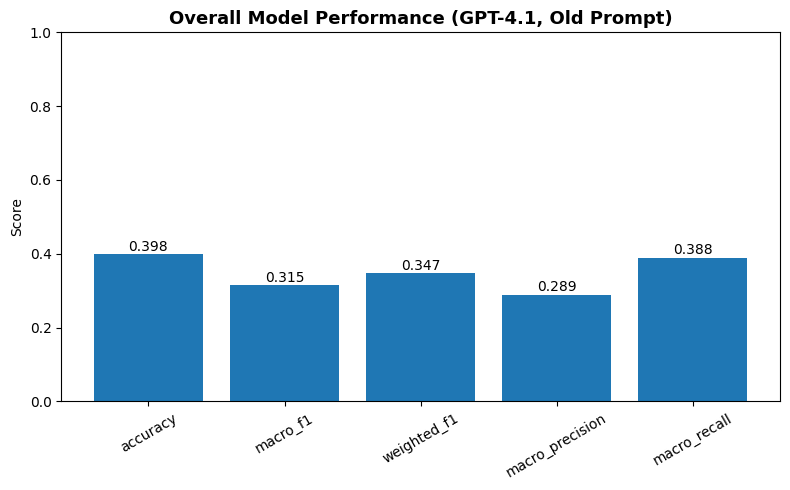

In [70]:
import matplotlib.pyplot as plt

metrics = ["accuracy", "macro_f1", "weighted_f1", "macro_precision", "macro_recall"]

vals = overall_results.iloc[0][metrics]
filtered = [(m, v) for m, v in zip(metrics, vals) if v > 1e-6]

metrics_clean, vals_clean = zip(*filtered)

plt.figure(figsize=(8,5))
plt.bar(metrics_clean, vals_clean)

plt.title("Overall Model Performance (GPT-4.1, Old Prompt)", fontsize=13, fontweight="bold")
plt.ylabel("Score")
plt.ylim(0,1)

for i, v in enumerate(vals_clean):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=10)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [66]:
df_plot = per_metaphor_results.copy()

# remove classes with no true examples
df_plot = df_plot[df_plot["support_true_n"] > 0]

# optional: also remove completely useless predictions
df_plot = df_plot[df_plot["f1"] > 0]

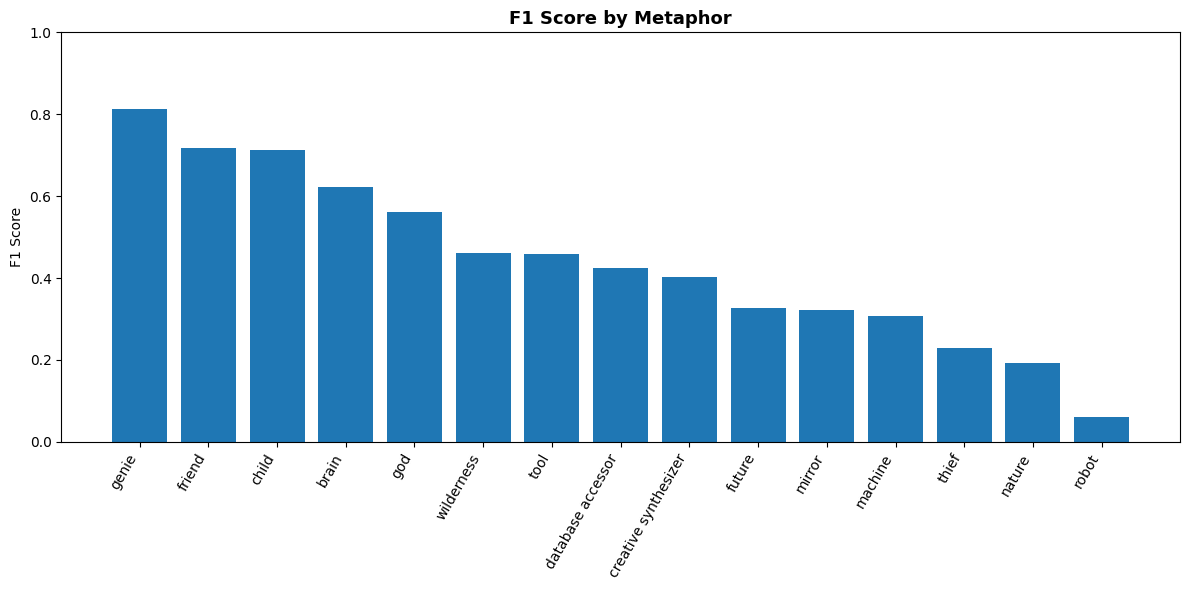

In [67]:
plt.figure(figsize=(12,6))
plt.bar(df_plot["metaphor"], df_plot["f1"])

plt.title("F1 Score by Metaphor", fontsize=13, fontweight="bold")
plt.ylabel("F1 Score")
plt.ylim(0,1)

plt.xticks(rotation=60, ha="right")

plt.tight_layout()
plt.show()

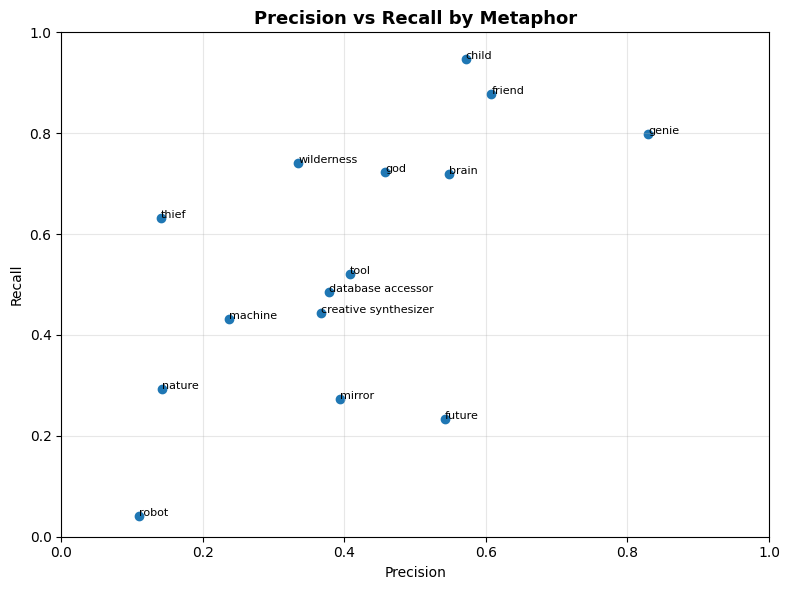

In [68]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_plot["precision"],
    df_plot["recall"]
)

for _, row in df_plot.iterrows():
    plt.text(row["precision"], row["recall"], row["metaphor"], fontsize=8)

plt.xlabel("Precision")
plt.ylabel("Recall")
plt.title("Precision vs Recall by Metaphor", fontsize=13, fontweight="bold")

plt.xlim(0,1)
plt.ylim(0,1)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

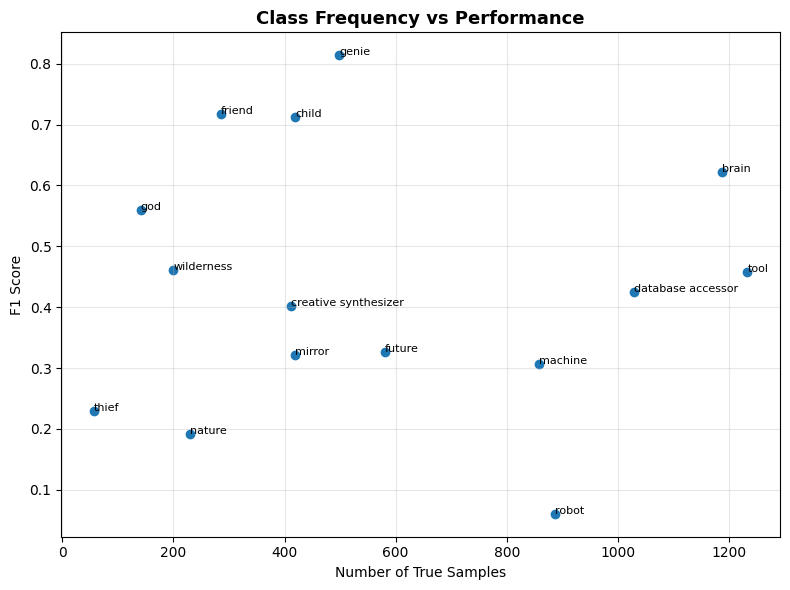

In [69]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_plot["support_true_n"],
    df_plot["f1"]
)

for _, row in df_plot.iterrows():
    plt.text(row["support_true_n"], row["f1"], row["metaphor"], fontsize=8)

plt.xlabel("Number of True Samples")
plt.ylabel("F1 Score")
plt.title("Class Frequency vs Performance", fontsize=13, fontweight="bold")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### **Interpretation: Count-Based / Aggregated Output**

The count-based prompt performs poorly across all aggregate metrics, with an accuracy of approximately 0.40 and a macro F1 score of around 0.31. This indicates that the model struggles to reliably identify the correct metaphor when required to output counts across multiple categories and when post-processing is used to infer a single dominant label.

At the class level, performance is highly uneven. The model achieves relatively strong F1 scores for more intuitive and anthropomorphic metaphors such as *genie*, *friend*, and *child*, suggesting that these categories are easier for the model to detect due to clearer semantic signals. In contrast, performance is substantially weaker for more abstract or system-oriented metaphors such as *robot*, *machine*, *nature*, and *thief*, which require more nuanced conceptual interpretation. These classes exhibit low recall and/or precision, indicating both missed detections and incorrect assignments.

The precision–recall analysis further reveals that the model is inconsistent in its predictions across categories. While some metaphors show balanced precision and recall, others suffer from very low recall, indicating that the model frequently fails to identify those metaphors even when they are present. Additionally, the relationship between class frequency and performance is weak: even high-frequency categories (e.g., *tool*, *machine*) do not achieve correspondingly high F1 scores. This suggests that the issue is not simply data imbalance but rather the model’s difficulty in mapping the prompt’s output structure to the intended classification task.

Overall, the results highlight a fundamental limitation of the count-based prompting approach. By asking the model to identify and count multiple metaphor families and then reducing this output to a single label via post-processing, the task introduces ambiguity and additional sources of error. The model is not explicitly optimized to select a single dominant metaphor, leading to diluted predictions and reduced alignment with the ground truth labels.
